# Evaluation Analysis for Recommender Output

In this section we will analyze and compare the generated recommendations and predictions from a predefined list of algorithms with the goal of assessing the performance of each algorithm with respect to a metric. In other words, we would rank the algorithms for each metric considered with respect to performance.

## Setup

Below are the list of packages required to successfully run the analysis. They are divided into partitions to signify their specific task.<br>
We need the pathlib package for working with files and folders

In [1]:
from pathlib import Path
import json

Load libraries for analysis and visualization:

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Import the LensKit metrics for analysis:

In [3]:
from lenskit.data import Dataset, ItemListCollection
from lenskit.metrics import RunAnalysis, RMSE, NDCG, RecipRank, RBP

In [4]:
from lkdemo.datasets import split_fraction

## Load Data

The recommendations are in `runs`, and we will need to reassemble the test data from `test`.

In [5]:
dataset = "ml-100k"

In [6]:
# Parameters
dataset = "ml-100k"


In [7]:
output_root = Path("runs")

In [8]:
dirs = [fld for fld in output_root.glob(f'{dataset}-*')]

In [9]:
recs = ItemListCollection(['model', 'user_id'], index=False)
for fld in dirs:
    for file in fld.glob("recs-*"):
        rec = ItemListCollection.load_parquet(file)
        recs.add_from(rec, model=fld.name.split("-")[-1])

In [10]:
rec_algos = sorted(set(a for (a, _u) in recs.keys()))
rec_algos

['ALS',
 'Bias',
 'FlexBPR',
 'FlexLMF',
 'FlexMF',
 'FlexWARP',
 'IALS',
 'IIE',
 'III',
 'LightGCN',
 'Pop',
 'UUE']

In [11]:
preds = ItemListCollection(['model', 'user_id'], index=False)
for fld in dirs:
    for file in fld.glob("pred-*"):
        pred = ItemListCollection.load_parquet(file)
        preds.add_from(pred, model=fld.name.split("-")[-1])

We need to load the test data so that we have the ground truths for computing accuracy.

In [12]:
data = Dataset.load(f"data/{dataset}")
split = split_fraction(data, 0.2)
test = split.test

And identify users in the training set, so we only report metrics over them.

In [13]:
train_users = split.train.user_stats()
train_users = train_users[train_users['rating_count'] > 0]

## Top-N Metrics

`RunListAnalysis` computes metrics for recommendation results and takes care of
matching recommendations and ground truth.

In [14]:
ra = RunAnalysis()

ra.add_metric(NDCG())
ra.add_metric(RecipRank())
ra.add_metric(RBP())

rec_results = ra.compute(recs, test)
rec_results.list_summary('model')

/home/mde48/lenskit/lk-demo-experiment/.venv/lib/python3.12/site-packages/lenskit/metrics/bulk.py:92: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = scores.groupby(list(keys)).agg(["mean", "median", "std"]).stack(level=0)


mean    median       std
model                                           
ALS      NDCG       0.161494  0.126464  0.120895
         RBP        0.175744  0.075306  0.200488
         RecipRank  0.235613  0.166667  0.261096
Bias     NDCG       0.163369  0.128442  0.122004
         RBP        0.177391  0.086458  0.195531
         RecipRank  0.228765  0.166667  0.242535
FlexBPR  NDCG       0.112383  0.076615  0.136831
         RBP        0.060865  0.009420  0.144404
         RecipRank  0.138137  0.047619  0.274833
FlexLMF  NDCG       0.111126  0.080027  0.131312
         RBP        0.059123  0.008938  0.140281
         RecipRank  0.128319  0.047619  0.250000
FlexMF   NDCG       0.068367  0.058942  0.065497
         RBP        0.026531  0.004210  0.064863
         RecipRank  0.076854  0.041667  0.173629
FlexWARP NDCG       0.113586  0.082171  0.138792
         RBP        0.057721  0.008938  0.137637
         RecipRank  0.140161  0.047619  0.279378
IALS     NDCG       0.097518  0.073652  0.110231
         RBP        0.046425  0.008404  0.104831
         RecipRank  0.106257  0.047619  0.214826
IIE      NDCG       0.028293  0.000000  0.063929
         RBP        0.014442  0.000000  0.055494
         RecipRank  0.036741  0.000000  0.133359
III      NDCG       0.051244  0.000000  0.125677
         RBP        0.044998  0.000000  0.150366
         RecipRank  0.078288  0.000000  0.233043
LightGCN NDCG       0.108787  0.078205  0.134928
         RBP        0.057284  0.008588  0.139995
         RecipRank  0.126089  0.047619  0.256427
Pop      NDCG       0.279687  0.268988  0.162487
         RBP        0.318951  0.250104  0.273319
         RecipRank  0.494082  0.250000  0.409474
UUE      NDCG       0.022112  0.000000  0.044289
         RBP        0.002570  0.000000  0.013186
         RecipRank  0.010190  0.000000  0.024621

We can reshape the list metrics and plot them, after filtering to only users with at least 1 training rating:

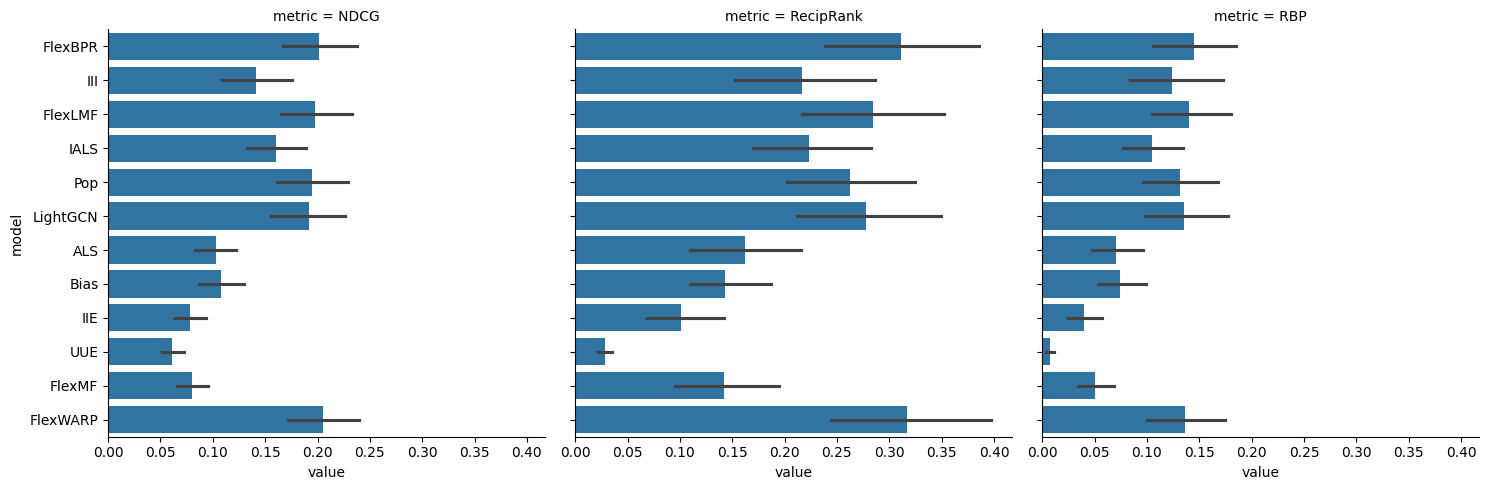

In [15]:
metrics = rec_results.list_metrics()
metrics = metrics.melt(var_name='metric', ignore_index=False).reset_index()
metrics = metrics[metrics['user_id'].isin(train_users.index)]
sns.catplot(metrics, y='model', x='value', col='metric', kind='bar')
plt.show()

Let's look at the influence of training ratings on performance, clamping 15+
into a single category — this helps understand perhaps surprising performance
relative to cross-fold evaluations:

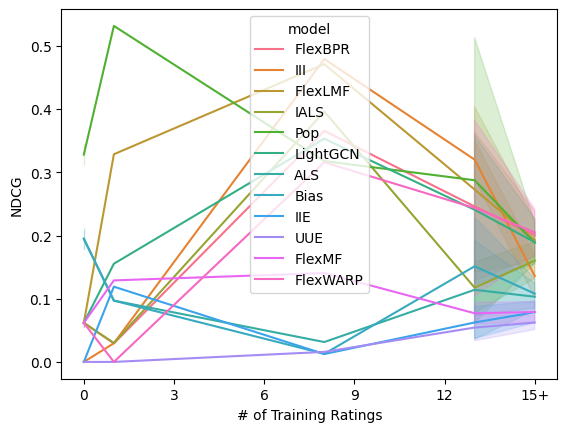

In [16]:
tcounts = split.train.user_stats()['rating_count'].copy()
tcounts[tcounts > 15] = 15
metrics = rec_results.list_metrics().reset_index().join(tcounts, on='user_id')
sns.lineplot(metrics, x='rating_count', y='NDCG', hue='model', errorbar='ci')
plt.xlabel('# of Training Ratings')
rc_ticks = np.arange(0, 16, 3)
plt.xticks(rc_ticks, rc_ticks[:-1].tolist() + ['15+'])
plt.show()

## Prediction RMSE

We will also look at the prediction RMSE.

In [17]:
pa = RunAnalysis()

pa.add_metric(RMSE(missing_scores='ignore', missing_truth='ignore'))

pred_results = pa.compute(preds, test)
pred_results.list_summary('model')

/home/mde48/lenskit/lk-demo-experiment/.venv/lib/python3.12/site-packages/lenskit/metrics/bulk.py:92: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = scores.groupby(list(keys)).agg(["mean", "median", "std"]).stack(level=0)


,,mean,median,std
model,,,,
ALS,RMSE,0.966643,0.943639,0.296128
Bias,RMSE,0.971431,0.945351,0.292602
FlexMF,RMSE,1.045115,1.063466,0.300817
IIE,RMSE,0.973457,0.944259,0.304926
UUE,RMSE,0.978119,0.958315,0.305261


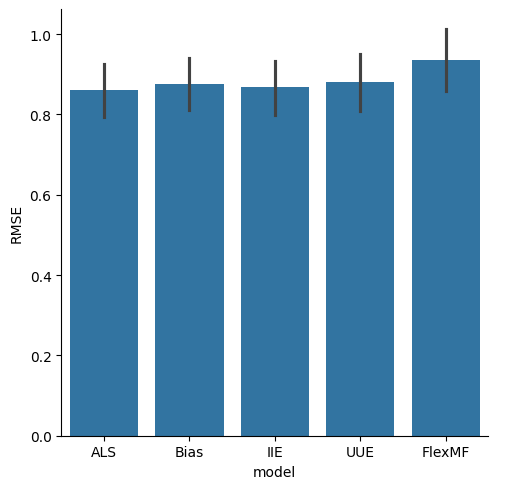

In [18]:
pred_metrics = pred_results.list_metrics().reset_index()
pred_metrics = pred_metrics[pred_metrics['user_id'].isin(train_users.index)]
sns.catplot(pred_metrics, x='model', y='RMSE', kind='bar')
plt.show()

## Save Metrics

We'll now save the metrics to a file.

In [19]:
rlsum = rec_results.list_summary('model')['mean'].unstack()
rlsum

/home/mde48/lenskit/lk-demo-experiment/.venv/lib/python3.12/site-packages/lenskit/metrics/bulk.py:92: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = scores.groupby(list(keys)).agg(["mean", "median", "std"]).stack(level=0)


,NDCG,RBP,RecipRank
model,,,
ALS,0.161494,0.175744,0.235613
Bias,0.163369,0.177391,0.228765
FlexBPR,0.112383,0.060865,0.138137
FlexLMF,0.111126,0.059123,0.128319
FlexMF,0.068367,0.026531,0.076854
FlexWARP,0.113586,0.057721,0.140161
IALS,0.097518,0.046425,0.106257
IIE,0.028293,0.014442,0.036741
III,0.051244,0.044998,0.078288


In [20]:
rlsum.to_json(f'eval-metrics.{dataset}.json', orient='index')